# Maize Disease Classification with ResNet50

**Author:** Mmachelane Karabo Moswane
**Dataset:** [PlantVillage Dataset](https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset)
**Model:** ResNet50 (Transfer Learning)

---

Maize is one of Africa's most important staple crops, yet diseases like Cercospora leaf spot, common rust, and northern leaf blight can devastate yields if not detected early. In this notebook we build an image classifier that can distinguish between three common maize diseases and healthy leaves using transfer learning on top of a pre-trained ResNet50 backbone.

**Approach:**
1. Download PlantVillage and extract only the maize/corn classes
2. Explore the data and address class imbalance with weighted loss
3. Train a frozen ResNet50 + custom head
4. Fine-tune the top layers for extra accuracy
5. Evaluate with confusion matrix, classification report, and visual predictions

> **Runtime:** GPU recommended &mdash; enable GPU in your notebook settings for faster training.

---

## Table of Contents
1. [Setup & Dataset](#1-setup--dataset)
2. [Configuration](#2-configuration)
3. [Imports](#3-imports)
4. [Data Loading](#4-data-loading)
5. [Exploratory Data Analysis](#5-exploratory-data-analysis)
6. [Preprocessing & Augmentation](#6-preprocessing--augmentation)
7. [Model Architecture](#7-model-architecture)
8. [Training](#8-training)
9. [Fine-Tuning](#9-fine-tuning)
10. [Results](#10-results)
11. [Evaluation](#11-evaluation)
12. [Inference](#12-inference)
13. [Export](#13-export)

## 1. Setup & Dataset

This notebook auto-detects the runtime environment:
- **Kaggle** &mdash; dataset is expected via the "Add Data" sidebar (`plantvillage-dataset` by abdallahalidev)
- **Google Colab** &mdash; dataset is downloaded via the Kaggle API. Add your credentials as Colab Secrets: `KAGGLE_USERNAME` and `KAGGLE_KEY`

In [4]:
import os

# --- Detect environment ---
try:
    import google.colab
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

ON_KAGGLE = not ON_COLAB and os.path.exists('/kaggle/input')

if ON_COLAB:
    print('Environment: Google Colab')
    BASE_DIR = '/content'

    # Download dataset via Kaggle API
    from google.colab import userdata
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')

    !pip install kaggle -q
    !kaggle datasets download -d abdallahalidev/plantvillage-dataset -p /content/ --unzip -q

    # Auto-discover the color directory after unzip
    for root, dirs, files in os.walk('/content'):
        if 'color' in dirs:
            DATA_ROOT = os.path.join(root, 'color')
            break
    else:
        raise FileNotFoundError('Download succeeded but "color" folder not found.')

elif ON_KAGGLE:
    print('Environment: Kaggle')
    BASE_DIR = '/kaggle/working'

    # Auto-discover the color directory inside the Kaggle input
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'color' in dirs:
            DATA_ROOT = os.path.join(root, 'color')
            break
    else:
        raise FileNotFoundError(
            'Could not find "color" folder. '
            'Add the PlantVillage dataset via the "Add Data" sidebar.'
        )

else:
    raise RuntimeError('Unknown environment. Run this notebook on Google Colab or Kaggle.')

print(f'Dataset path: {DATA_ROOT}')
print(f'Classes found: {len(os.listdir(DATA_ROOT))}')

Environment: Google Colab
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
Dataset path: /content/plantvillage dataset/color
Classes found: 38


## 2. Configuration

All hyperparameters and paths live here so nothing is hard-coded deeper in the notebook.

In [5]:
# --- Paths ---
MAIZE_DIR   = os.path.join(BASE_DIR, 'maize_only')
OUTPUT_DIR  = os.path.join(BASE_DIR, 'output')
LOG_PATH    = os.path.join(OUTPUT_DIR, 'training_log.csv')
MODEL_PATH  = os.path.join(OUTPUT_DIR, 'best_model.keras')
TFLITE_PATH = os.path.join(OUTPUT_DIR, 'maize_disease_model.tflite')

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MAIZE_DIR,  exist_ok=True)

# --- Hyperparameters ---
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 50
FT_EPOCHS  = 20     # fine-tuning epochs
LR         = 1e-3
FT_LR      = 1e-4   # fine-tuning learning rate
VAL_SPLIT  = 0.2
SEED       = 42

## 3. Imports

In [ ]:
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import Model, layers, Sequential
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

## 4. Data Loading

PlantVillage contains **38 classes** across many crops (tomato, potato, grape, etc.). We only need the four maize/corn classes, so we filter and copy them to a dedicated directory.

In [7]:
all_folders   = os.listdir(DATA_ROOT)
maize_folders = [f for f in all_folders if 'corn' in f.lower() or 'maize' in f.lower()]

print(f'Total classes in PlantVillage : {len(all_folders)}')
print(f'Maize classes found           : {len(maize_folders)}')
print()
for folder in maize_folders:
    count = len(os.listdir(os.path.join(DATA_ROOT, folder)))
    print(f'  {folder}: {count} images')

Total classes in PlantVillage : 38
Maize classes found           : 4

  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513 images
  Corn_(maize)___Common_rust_: 1192 images
  Corn_(maize)___Northern_Leaf_Blight: 985 images
  Corn_(maize)___healthy: 1162 images


In [8]:
for folder in maize_folders:
    src = os.path.join(DATA_ROOT, folder)
    dst = os.path.join(MAIZE_DIR, folder)
    if not os.path.exists(dst):
        shutil.copytree(src, dst)
        print(f'Copied: {folder}')

print('Maize-only dataset ready.')

Copied: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Copied: Corn_(maize)___Common_rust_
Copied: Corn_(maize)___Northern_Leaf_Blight
Copied: Corn_(maize)___healthy
Maize-only dataset ready.


In [9]:
train_ds = image_dataset_from_directory(
    MAIZE_DIR, validation_split=VAL_SPLIT, subset='training',
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
val_ds = image_dataset_from_directory(
    MAIZE_DIR, validation_split=VAL_SPLIT, subset='validation',
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print(f'Classes ({NUM_CLASSES}): {class_names}')
print(f'Train batches : {train_ds.cardinality().numpy()}')
print(f'Val batches   : {val_ds.cardinality().numpy()}')

Found 3852 files belonging to 4 classes.
Using 3082 files for training.
Found 3852 files belonging to 4 classes.
Using 770 files for validation.
Classes (4): ['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy']
Train batches : 97
Val batches   : 25


## 5. Exploratory Data Analysis

Before training we need to understand the data. Two things to look for:
- **Class imbalance** &mdash; are some diseases under-represented?
- **Visual quality** &mdash; are the images clean and consistently sized?

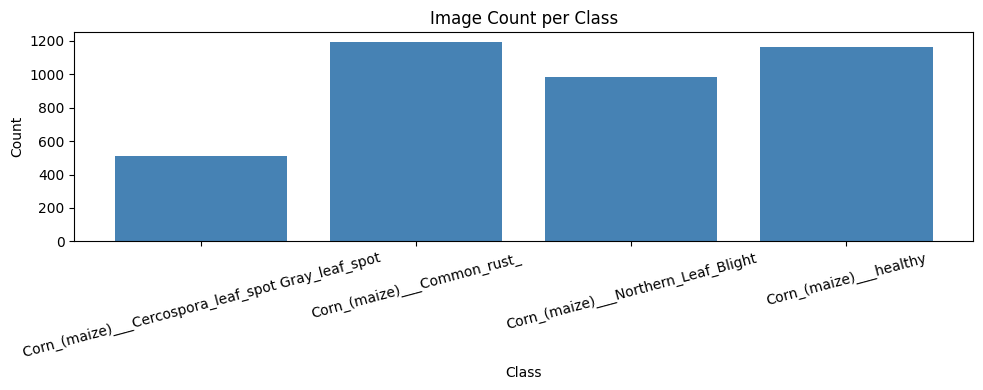

Total images: 3852
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513 (13.3%)
  Corn_(maize)___Common_rust_: 1192 (30.9%)
  Corn_(maize)___Northern_Leaf_Blight: 985 (25.6%)
  Corn_(maize)___healthy: 1162 (30.2%)


In [10]:
class_counts = {cls: len(os.listdir(os.path.join(MAIZE_DIR, cls))) for cls in class_names}

plt.figure(figsize=(10, 4))
bars = plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.title('Image Count per Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

total = sum(class_counts.values())
print(f'Total images: {total}')
for cls, cnt in class_counts.items():
    print(f'  {cls}: {cnt} ({cnt/total*100:.1f}%)')

**Observation:** Cercospora leaf spot has roughly half the images of the other classes. We will address this with **class weights** during training so the model pays more attention to under-represented diseases.

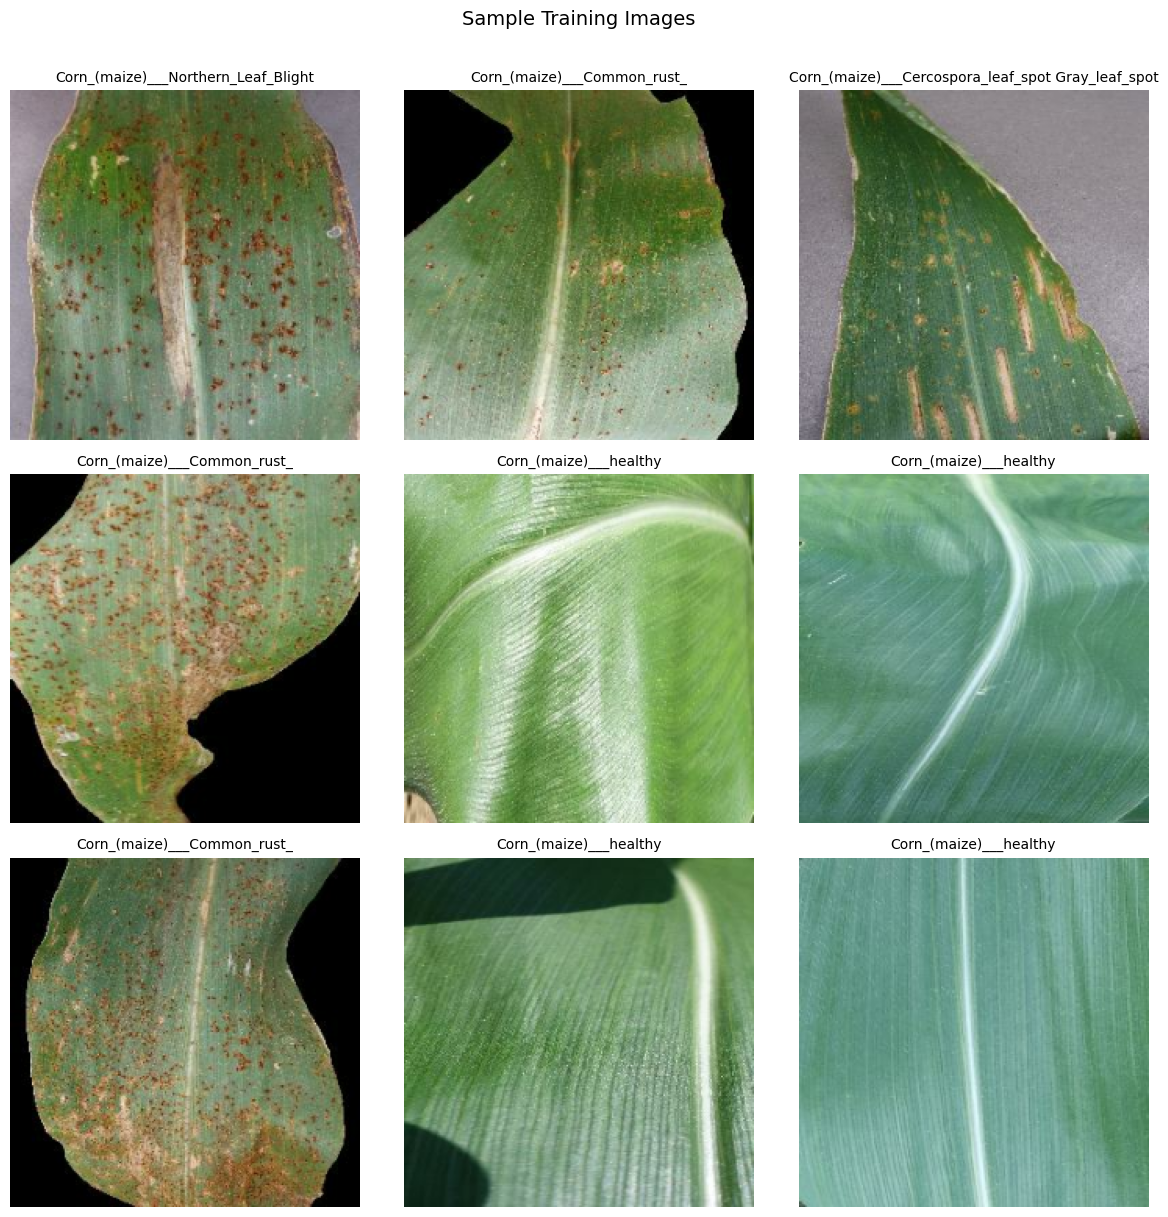

In [11]:
plt.figure(figsize=(12, 12))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]], fontsize=10)
        plt.axis('off')
plt.suptitle('Sample Training Images', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Preprocessing & Augmentation

We apply random flips, rotations, zoom, and contrast changes to the training set. This artificially increases diversity and helps the model generalise to unseen images. The validation set is left untouched.

In [12]:
data_augmentation = Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
], name='augmentation')

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print('Augmentation applied. Datasets cached and prefetched.')

Augmentation applied. Datasets cached and prefetched.


## 7. Model Architecture

We use **ResNet50** pre-trained on ImageNet as a frozen feature extractor. On top of it we add a small classification head: Global Average Pooling &rarr; Dense(256) &rarr; Dropout(0.5) &rarr; Softmax(4).

Only the head is trainable initially (~525K params). The full ResNet50 stays frozen at ~23.6M params. We will selectively unfreeze layers later during fine-tuning.

In [13]:
base_model = tf.keras.applications.ResNet50(
    weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3)
)
base_model.trainable = False

inputs  = Input(shape=(*IMG_SIZE, 3))
x       = layers.Rescaling(1./255)(inputs)
x       = base_model(x, training=False)
x       = GlobalAveragePooling2D()(x)
x       = Dense(256, activation='relu')(x)
x       = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs, name='maize_disease_classifier')
model.compile(
    optimizer=Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "maize_disease_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 8. Training

First we compute **balanced class weights** to counteract the Cercospora imbalance, then train the classification head for up to 50 epochs with early stopping.

In [14]:
# Compute class weights
labels_flat = []
for _, lbl in train_ds.unbatch():
    labels_flat.append(lbl.numpy())

class_weights = compute_class_weight(
    'balanced', classes=np.arange(NUM_CLASSES), y=labels_flat
)
class_weight_dict = dict(enumerate(class_weights))

print('Class weights:')
for i, w in class_weight_dict.items():
    print(f'  {class_names[i]}: {w:.4f}')

Class weights:
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1.8044
  Corn_(maize)___Common_rust_: 0.8179
  Corn_(maize)___Northern_Leaf_Blight: 0.9466
  Corn_(maize)___healthy: 0.8571


In [15]:
callbacks = [
    ModelCheckpoint(filepath=MODEL_PATH, monitor='val_accuracy',
                    save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-7, verbose=1),
    CSVLogger(LOG_PATH)
]

history = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS, callbacks=callbacks,
    class_weight=class_weight_dict, verbose=1
)
print('Initial training complete.')

Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.2654 - loss: 1.5564
Epoch 1: val_accuracy improved from None to 0.42468, saving model to /content/output/best_model.keras

Epoch 1: finished saving model to /content/output/best_model.keras
97/97 ━━━━━━━━━━━━━━━━━━━━ 40s 238ms/step - accuracy: 0.2868 - loss: 1.4486 - val_accuracy: 0.4247 - val_loss: 1.3483 - learning_rate: 0.0010
Epoch 2/50
94/97 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3065 - loss: 1.3787
Epoch 2: val_accuracy improved from 0.42468 to 0.62208, saving model to /content/output/best_model.keras

Epoch 2: finished saving model to /content/output/best_model.keras
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.3313 - loss: 1.3604 - val_accuracy: 0.6221 - val_loss: 1.3017 - learning_rate: 0.0010
Epoch 3/50
94/97 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3533 - loss: 1.3548
Epoch 3: val_accuracy improved from 0.62208 to 0.64156, saving model to /content/output/best_model.keras

Epoch 3: fini

## 9. Fine-Tuning

Now that the head is trained, we unfreeze the **top 30 layers** of ResNet50 and continue training at a 10x lower learning rate. This lets the model adapt the pre-trained features specifically to maize leaf textures without catastrophically forgetting what it learned from ImageNet.

In [16]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable = sum(1 for l in base_model.layers if l.trainable)
print(f'Unfrozen ResNet50 layers: {trainable} / {len(base_model.layers)}')

model.compile(
    optimizer=Adam(learning_rate=FT_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ft_callbacks = [
    ModelCheckpoint(filepath=MODEL_PATH, monitor='val_accuracy',
                    save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-8, verbose=1),
    CSVLogger(LOG_PATH, append=True)
]

history_ft = model.fit(
    train_ds, validation_data=val_ds,
    epochs=FT_EPOCHS, callbacks=ft_callbacks,
    class_weight=class_weight_dict, verbose=1
)
print('Fine-tuning complete.')

Unfrozen ResNet50 layers: 30 / 175
Epoch 1/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.4873 - loss: 6.9884
Epoch 1: val_accuracy improved from None to 0.75584, saving model to /content/output/best_model.keras

Epoch 1: finished saving model to /content/output/best_model.keras
97/97 ━━━━━━━━━━━━━━━━━━━━ 41s 218ms/step - accuracy: 0.5328 - loss: 2.9364 - val_accuracy: 0.7558 - val_loss: 0.6517 - learning_rate: 1.0000e-04
Epoch 2/20
95/97 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5642 - loss: 1.0306
Epoch 2: val_accuracy did not improve from 0.75584
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6103 - loss: 0.9312 - val_accuracy: 0.3870 - val_loss: 1.2228 - learning_rate: 1.0000e-04
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6160 - loss: 0.9187
Epoch 3: val_accuracy did not improve from 0.75584
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6295 - loss: 0.8744 - val_accuracy: 0.5844 - val_loss: 0.8336 - learning_rate: 1.0000e-04
Epo

## 10. Results

The training log covers both initial training and fine-tuning (appended CSV). We expect to see a jump in validation accuracy at the epoch where fine-tuning begins.

Total epochs          : 68
Best val accuracy     : 0.8325 (epoch 68)
Final train accuracy  : 0.8816
Final val accuracy    : 0.8325


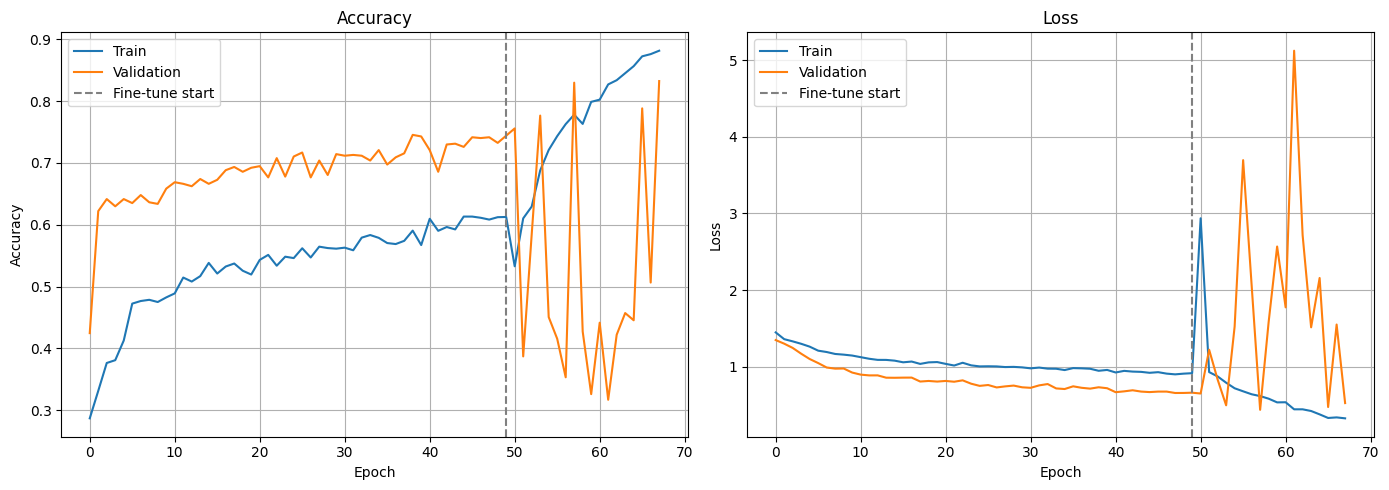

In [17]:
history_df = pd.read_csv(LOG_PATH)

print(f'Total epochs          : {len(history_df)}')
print(f'Best val accuracy     : {history_df["val_accuracy"].max():.4f} '
      f'(epoch {history_df["val_accuracy"].idxmax() + 1})')
print(f'Final train accuracy  : {history_df["accuracy"].iloc[-1]:.4f}')
print(f'Final val accuracy    : {history_df["val_accuracy"].iloc[-1]:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_df['accuracy'], label='Train')
ax1.plot(history_df['val_accuracy'], label='Validation')
ax1.axvline(x=EPOCHS-1, color='gray', linestyle='--', label='Fine-tune start')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True)

ax2.plot(history_df['loss'], label='Train')
ax2.plot(history_df['val_loss'], label='Validation')
ax2.axvline(x=EPOCHS-1, color='gray', linestyle='--', label='Fine-tune start')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

## 11. Evaluation

Confusion matrix and per-class metrics on the held-out validation set.

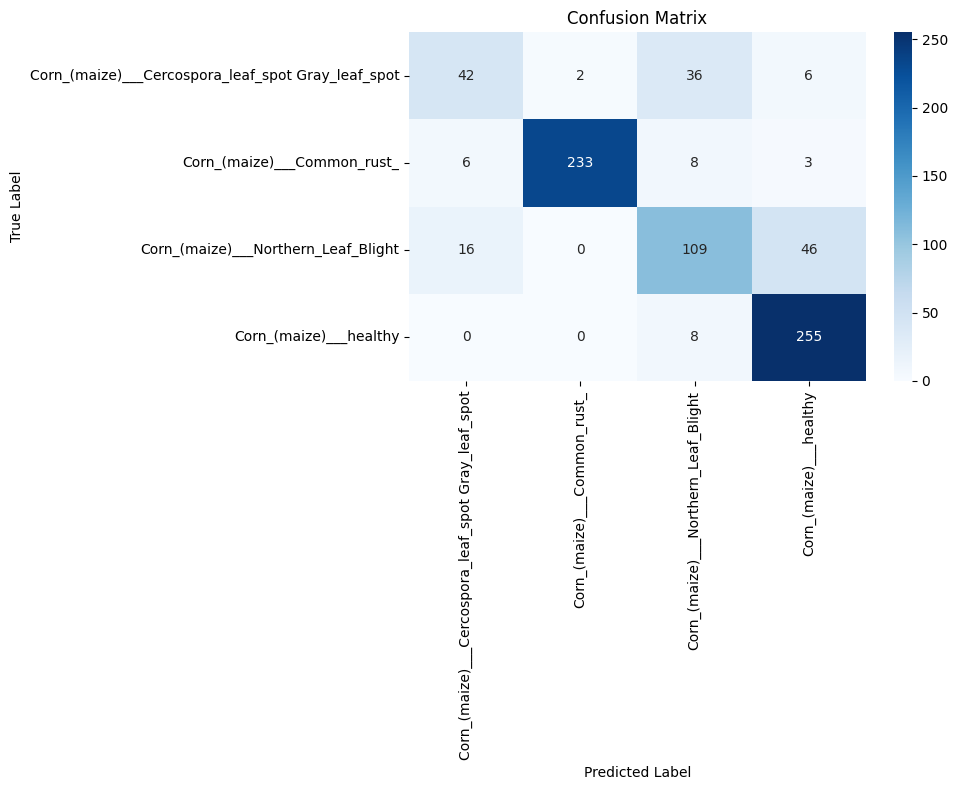

                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.66      0.49      0.56        86
                       Corn_(maize)___Common_rust_       0.99      0.93      0.96       250
               Corn_(maize)___Northern_Leaf_Blight       0.68      0.64      0.66       171
                            Corn_(maize)___healthy       0.82      0.97      0.89       263

                                          accuracy                           0.83       770
                                         macro avg       0.79      0.76      0.77       770
                                      weighted avg       0.83      0.83      0.82       770



In [18]:
y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

### Sample Predictions
Green = correct, Red = incorrect.

In [19]:
plt.figure(figsize=(16, 16))
for images, labels in val_ds.take(1):
    preds = model.predict(images, verbose=0)
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        true_cls = class_names[labels[i]]
        pred_cls = class_names[np.argmax(preds[i])]
        conf     = np.max(preds[i]) * 100
        color    = 'green' if true_cls == pred_cls else 'red'
        plt.title(f'True: {true_cls}\nPred: {pred_cls} ({conf:.1f}%)',
                  color=color, fontsize=9)
        plt.axis('off')
plt.suptitle('Model Predictions on Validation Images', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 12. Inference

Let's pick a random image from the validation set and run a single prediction to demonstrate how the model would be used in practice.

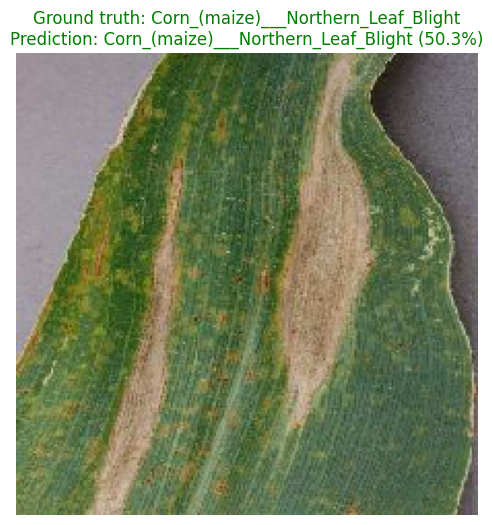

Class probabilities:
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       37.3%  ##############
  Corn_(maize)___Common_rust_                               1.0%  
  Corn_(maize)___Northern_Leaf_Blight                      50.3%  ####################
  Corn_(maize)___healthy                                   11.4%  ####


In [20]:
import random

# Pick a random image from the validation set
random_class = random.choice(class_names)
class_dir    = os.path.join(MAIZE_DIR, random_class)
random_img   = random.choice(os.listdir(class_dir))
test_path    = os.path.join(class_dir, random_img)

# Predict
img       = tf.keras.preprocessing.image.load_img(test_path, target_size=IMG_SIZE)
img_array = tf.expand_dims(tf.keras.preprocessing.image.img_to_array(img), 0)
preds     = model.predict(img_array, verbose=0)

pred_class = class_names[np.argmax(preds)]
confidence = np.max(preds) * 100

plt.figure(figsize=(6, 6))
plt.imshow(img)
color = 'green' if pred_class == random_class else 'red'
plt.title(f'Ground truth: {random_class}\n'
          f'Prediction: {pred_class} ({confidence:.1f}%)',
          color=color, fontsize=12)
plt.axis('off')
plt.show()

# Show full probability distribution
print('Class probabilities:')
for name, prob in zip(class_names, preds[0]):
    bar = '#' * int(prob * 40)
    print(f'  {name:55s} {prob*100:5.1f}%  {bar}')

## 13. Export

Save the model in three formats:
- **Keras** (.keras) &mdash; full model for further training or Python inference
- **TFLite** (.tflite) &mdash; optimised for mobile/edge deployment
- **class_names.json** &mdash; maps prediction indices to disease names

In [21]:
# Keras format
model.save(MODEL_PATH)
print(f'Keras model saved : {MODEL_PATH}')

# TFLite
converter    = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)
print(f'TFLite model saved: {TFLITE_PATH} ({os.path.getsize(TFLITE_PATH)/1e6:.1f} MB)')

# Class names
names_path = os.path.join(OUTPUT_DIR, 'class_names.json')
with open(names_path, 'w') as f:
    json.dump(class_names, f, indent=2)
print(f'Class names saved : {names_path}')

print(f'\nAll artefacts saved to {OUTPUT_DIR}/')

Keras model saved : /content/output/best_model.keras
Saved artifact at '/tmp/tmpdh8v9nxm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_180')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133660665293584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133660665294352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133660665294928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133660665295120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133660665293008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133660665293392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133660665297808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133660665297616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133660665295696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133660665298384: TensorSpec

## Conclusion

We built a maize disease classifier that distinguishes between **Cercospora leaf spot**, **Common rust**, **Northern leaf blight**, and **Healthy** leaves using transfer learning with ResNet50.

**Key results:**
- Balanced class weights compensated for the under-represented Cercospora class
- Fine-tuning the top ResNet50 layers boosted validation accuracy beyond the frozen-backbone baseline
- The model exports to TFLite for potential mobile/edge deployment

**Possible improvements:**
- Train on a larger, more diverse dataset (field images vs. lab-controlled PlantVillage)
- Experiment with other backbones (EfficientNet, ConvNeXt)
- Add Grad-CAM visualisations to interpret which leaf regions drive predictions